In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [3]:
from google.colab import files

uploaded = files.upload()


Saving archive (7).zip to archive (7).zip


In [4]:
import os

print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)


Uploaded files:
archive (7).zip


In [5]:
import zipfile
import os

zip_filename = next(iter(uploaded.keys()))

extract_path = "/content/heart_disease_data"

with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:")
for root, dirs, filenames in os.walk(extract_path):
    for filename in filenames:
        print(os.path.join(root, filename))

Extracted files:
/content/heart_disease_data/heart_disease_uci.csv


In [6]:
import os

for root, dirs, files in os.walk(extract_path):
    for file in files:
        #print(file)
        print(os.path.join(root, file))

/content/heart_disease_data/heart_disease_uci.csv


In [7]:
data_file = "/content/heart_disease_data/heart_disease_uci.csv"

df = pd.read_csv(data_file)

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [8]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Dataset shape: (920, 16)

Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [9]:
missing = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df)) * 100
})

missing_summary

,Missing Values,Percentage
id,0,0.000000
age,0,0.000000
sex,0,0.000000
dataset,0,0.000000
cp,0,0.000000
trestbps,59,6.413043
chol,30,3.260870
fbs,90,9.782609
restecg,2,0.217391
thalch,55,5.978261


In [10]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [11]:
df["num"].value_counts().sort_index()

,count
num,
0,411
1,265
2,109
3,107
4,28


In [12]:
df["heart_disease"] = (
    df["num"] > 0
).astype(int)

df["heart_disease"].value_counts()

,count
heart_disease,
1,509
0,411


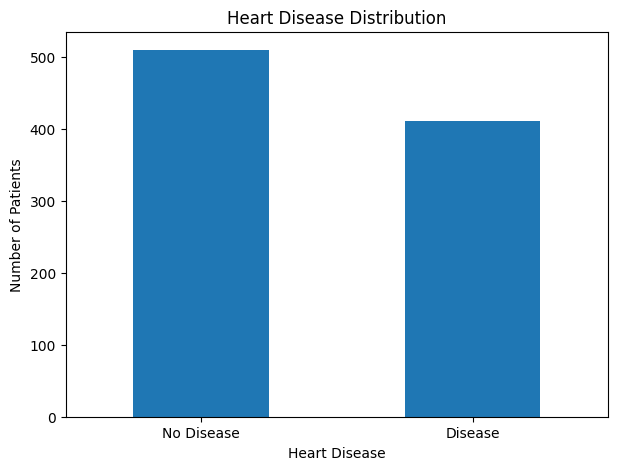

In [13]:
df["heart_disease"].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"],
    rotation=0
)

plt.show()

In [14]:
target_percentage = (
    df["heart_disease"]
    .value_counts(normalize=True)
    * 100
)

target_percentage

,proportion
heart_disease,
1,55.326087
0,44.673913


In [15]:
df_model = df.drop(
    columns=[
        "id",
        "num"
    ]
)

df_model.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,heart_disease
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


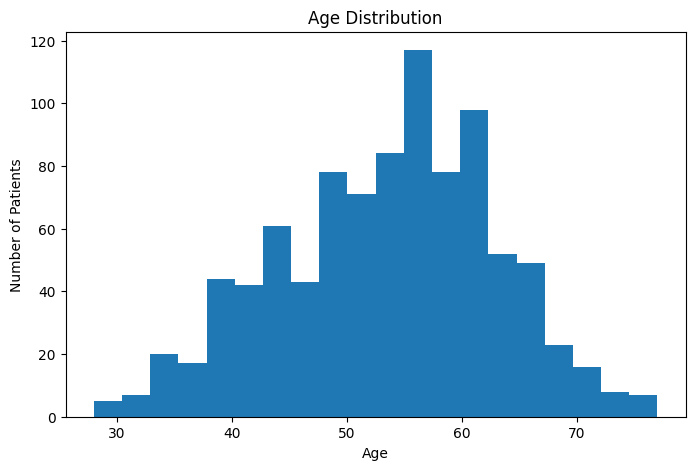

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_model["age"].dropna(),
    bins=20
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

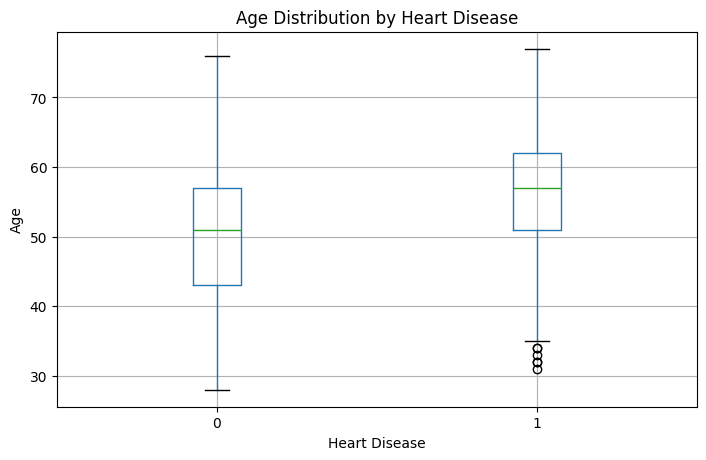

In [17]:
df_model.boxplot(
    column="age",
    by="heart_disease",
    figsize=(8, 5)
)

plt.title("Age Distribution by Heart Disease")
plt.suptitle("")

plt.xlabel("Heart Disease")
plt.ylabel("Age")

plt.show()

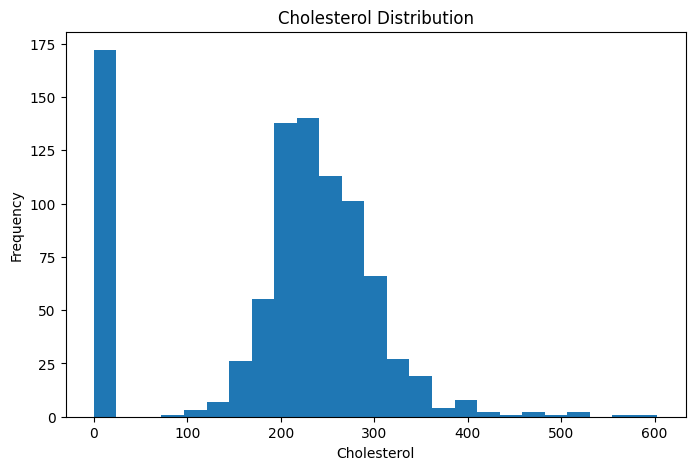

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_model["chol"].dropna(),
    bins=25
)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.show()

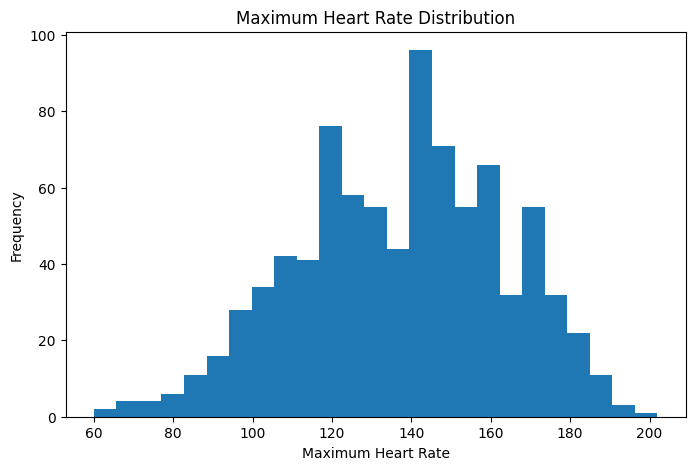

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_model["thalch"].dropna(),
    bins=25
)

plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Maximum Heart Rate")
plt.ylabel("Frequency")

plt.show()

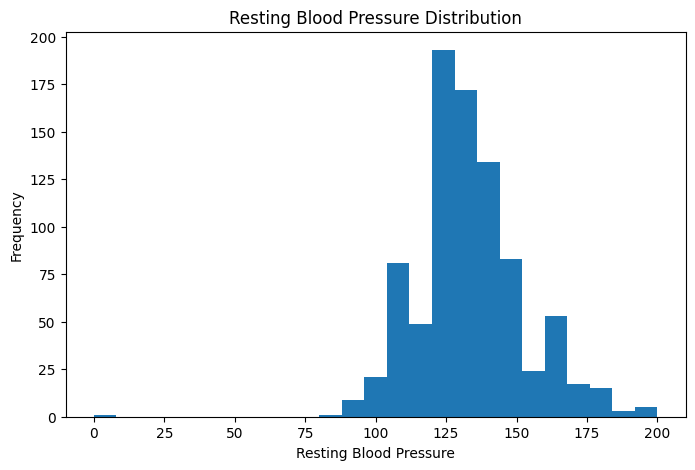

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_model["trestbps"].dropna(),
    bins=25
)

plt.title("Resting Blood Pressure Distribution")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Frequency")

plt.show()

In [21]:
pd.crosstab(
    df_model["sex"],
    df_model["heart_disease"],
    normalize="index"
) * 100

heart_disease,0,1
sex,,
Female,74.226804,25.773196
Male,36.776860,63.223140


In [22]:
pd.crosstab(
    df_model["cp"],
    df_model["heart_disease"],
    normalize="index"
) * 100

heart_disease,0,1
cp,,
asymptomatic,20.967742,79.032258
atypical angina,86.206897,13.793103
non-anginal,64.215686,35.784314
typical angina,56.521739,43.478261


In [23]:
pd.crosstab(
    df_model["exang"],
    df_model["heart_disease"],
    normalize="index"
) * 100

heart_disease,0,1
exang,,
False,63.636364,36.363636
True,16.320475,83.679525


In [24]:
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca",
    "heart_disease"
]

correlation = df_model[
    numeric_features
].corr()

correlation

,age,trestbps,chol,thalch,oldpeak,ca,heart_disease
age,1.000000,0.244253,-0.086234,-0.365778,0.258243,0.370416,0.282700
trestbps,0.244253,1.000000,0.092853,-0.104899,0.161908,0.093705,0.106233
chol,-0.086234,0.092853,1.000000,0.236121,0.047734,0.051606,-0.230583
thalch,-0.365778,-0.104899,0.236121,1.000000,-0.151174,-0.264094,-0.394503
oldpeak,0.258243,0.161908,0.047734,-0.151174,1.000000,0.281817,0.385528
ca,0.370416,0.093705,0.051606,-0.264094,0.281817,1.000000,0.455599
heart_disease,0.282700,0.106233,-0.230583,-0.394503,0.385528,0.455599,1.000000


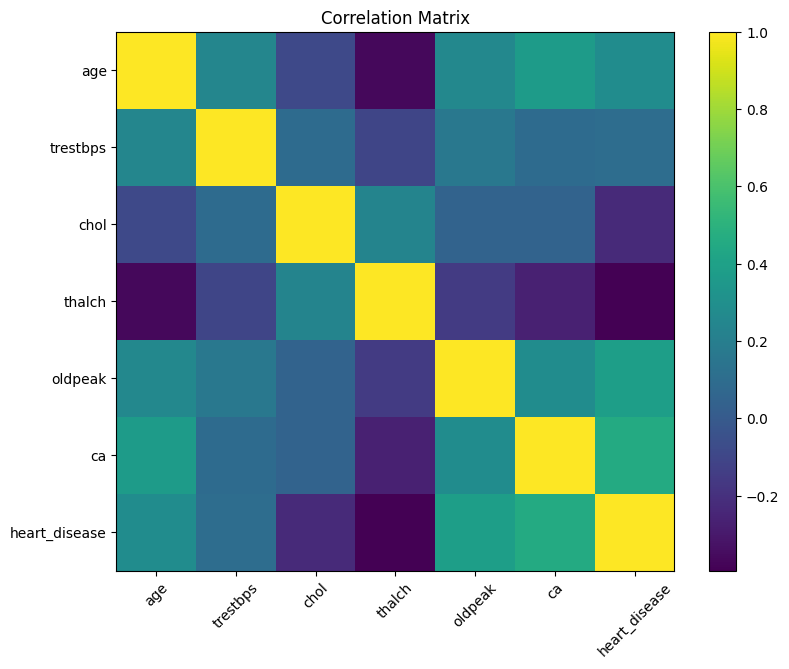

In [25]:
plt.figure(figsize=(9, 7))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title(
    "Correlation Matrix"
)

plt.show()

In [26]:
X = df_model.drop(
    columns=["heart_disease"]
)

y = df_model["heart_disease"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (920, 14)
Target: (920,)


In [27]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

Categorical features:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

Training samples: 736
Testing samples: 184


In [29]:
numeric_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [30]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_preprocessor,
        numeric_features
    ),
    (
        "categorical",
        categorical_preprocessor,
        categorical_features
    )
])

In [31]:
logistic_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

logistic_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak', 'ca']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'dataset', 'cp',
                                                   'fbs', 'restecg', 'exang',
                                                   'slope', 'thal'])])),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [32]:
lr_predictions = (
    logistic_pipeline
    .predict(X_test)
)

lr_probabilities = (
    logistic_pipeline
    .predict_proba(X_test)[:, 1]
)

In [33]:
rf_numeric_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    )
])

rf_categorical_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

rf_preprocessor = ColumnTransformer([
    (
        "numeric",
        rf_numeric_preprocessor,
        numeric_features
    ),
    (
        "categorical",
        rf_categorical_preprocessor,
        categorical_features
    )
])

In [34]:
rf_pipeline = Pipeline([
    (
        "preprocessor",
        rf_preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        )
    )
])

rf_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak', 'ca']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'dataset', 'cp',
                                                   'fbs', 'restecg', 'exang',
                                                   'slope', 'thal'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [35]:
rf_predictions = (
    rf_pipeline
    .predict(X_test)
)

rf_probabilities = (
    rf_pipeline
    .predict_proba(X_test)[:, 1]
)

In [36]:
def evaluate_model(
    model_name,
    y_true,
    predictions,
    probabilities
):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions
        ),
        "Recall": recall_score(
            y_true,
            predictions
        ),
        "F1 Score": f1_score(
            y_true,
            predictions
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        )
    }

In [37]:
results = [
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_predictions,
        lr_probabilities
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions,
        rf_probabilities
    )
]

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.836957,0.827273,0.892157,0.858491,0.920373
1,Random Forest,0.853261,0.857143,0.882353,0.869565,0.928563


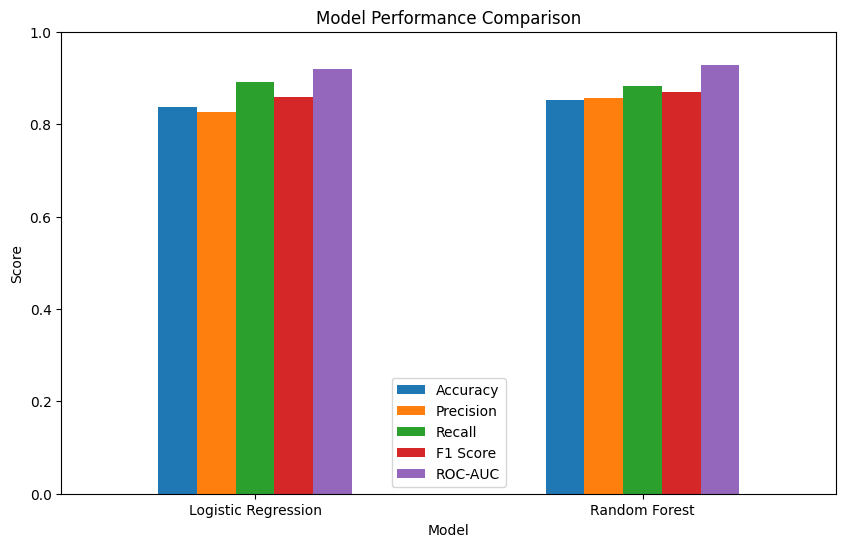

In [38]:
results_df.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

In [39]:
print("LOGISTIC REGRESSION")
print(
    classification_report(
        y_test,
        lr_predictions
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



In [40]:
print("RANDOM FOREST")
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.85      0.82      0.83        82
           1       0.86      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



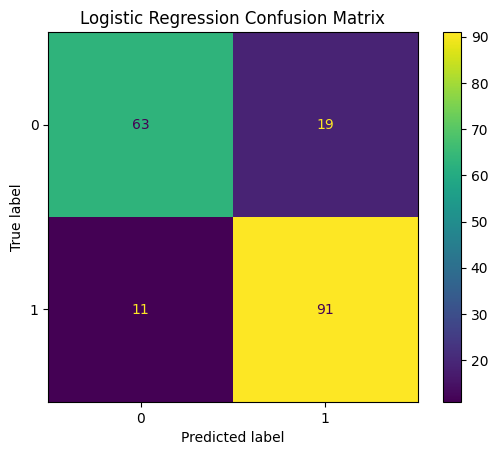

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_predictions
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

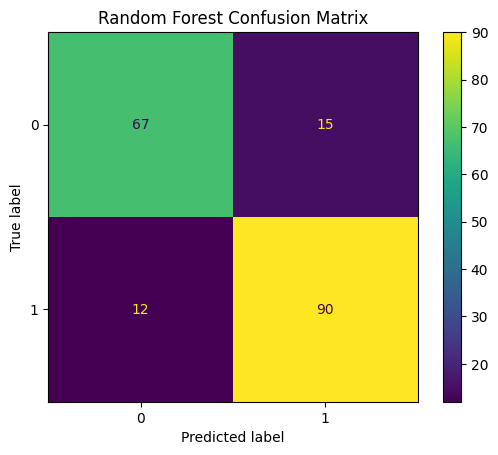

In [42]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

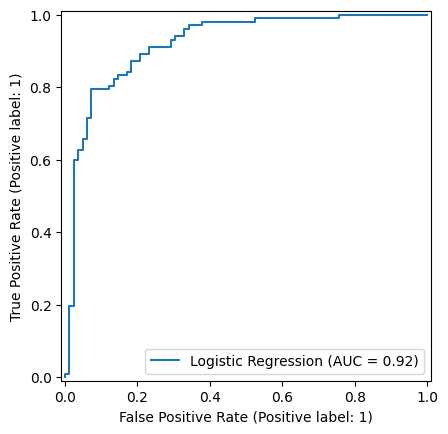

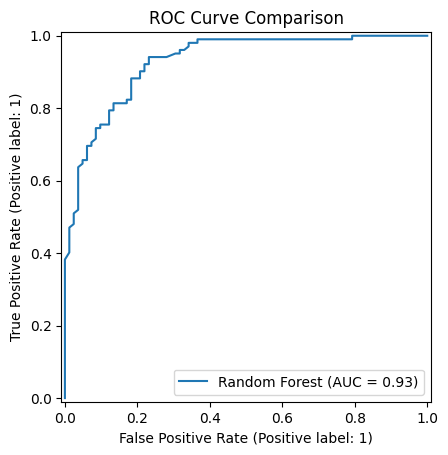

In [43]:
RocCurveDisplay.from_predictions(
    y_test,
    lr_probabilities,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_probabilities,
    name="Random Forest"
)

plt.title(
    "ROC Curve Comparison"
)

plt.show()

In [44]:
def risk_category(probability):

    if probability < 0.30:
        return "Low"

    elif probability < 0.70:
        return "Moderate"

    else:
        return "High"

In [45]:
risk_results = X_test.copy()

risk_results["Actual"] = (
    y_test.values
)

risk_results["Probability"] = (
    rf_probabilities
)

risk_results["Risk Category"] = (
    risk_results["Probability"]
    .apply(risk_category)
)

risk_results.head(10)

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,Actual,Probability,Risk Category
514,49,Male,Hungary,asymptomatic,130.0,206.0,False,normal,170.0,False,0.0,NaN,NaN,NaN,1,0.460000,Moderate
825,61,Male,VA Long Beach,asymptomatic,120.0,282.0,False,st-t abnormality,135.0,True,4.0,downsloping,NaN,fixed defect,1,0.883333,High
854,55,Male,VA Long Beach,asymptomatic,172.0,260.0,False,normal,73.0,False,2.0,NaN,NaN,NaN,1,0.780000,High
804,65,Male,VA Long Beach,asymptomatic,136.0,248.0,False,normal,140.0,True,4.0,downsloping,NaN,NaN,1,0.986667,High
887,69,Male,VA Long Beach,non-anginal,NaN,271.0,False,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0,0.750000,High
483,59,Male,Hungary,non-anginal,130.0,318.0,False,normal,120.0,True,1.0,flat,NaN,normal,0,0.720000,High
273,71,Female,Cleveland,asymptomatic,112.0,149.0,False,normal,125.0,False,1.6,flat,0.0,normal,0,0.306667,Moderate
540,50,Male,Hungary,asymptomatic,130.0,233.0,False,normal,121.0,True,2.0,flat,NaN,reversable defect,1,0.983333,High
402,48,Male,Hungary,atypical angina,140.0,238.0,False,normal,118.0,False,0.0,NaN,NaN,NaN,0,0.013333,Low
601,38,Female,Switzerland,asymptomatic,105.0,0.0,NaN,normal,166.0,False,2.8,upsloping,NaN,NaN,1,0.813333,High


In [46]:
risk_results[
    "Risk Category"
].value_counts()

,count
Risk Category,
High,86
Low,55
Moderate,43


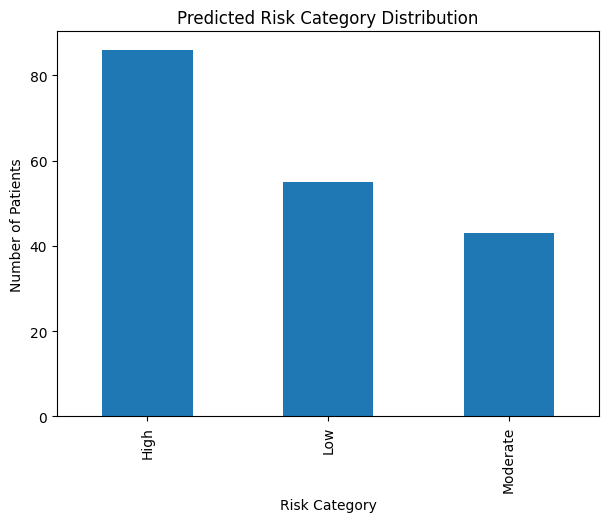

In [47]:
risk_results[
    "Risk Category"
].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title(
    "Predicted Risk Category Distribution"
)

plt.xlabel("Risk Category")
plt.ylabel("Number of Patients")

plt.show()

In [48]:
rf_model = (
    rf_pipeline
    .named_steps["model"]
)

rf_model

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [49]:
feature_names = (
    rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print(
    "Number of transformed features:",
    len(feature_names)
)

feature_names

Number of transformed features: 29


array(['numeric__age', 'numeric__trestbps', 'numeric__chol',
       'numeric__thalch', 'numeric__oldpeak', 'numeric__ca',
       'categorical__sex_Female', 'categorical__sex_Male',
       'categorical__dataset_Cleveland', 'categorical__dataset_Hungary',
       'categorical__dataset_Switzerland',
       'categorical__dataset_VA Long Beach',
       'categorical__cp_asymptomatic', 'categorical__cp_atypical angina',
       'categorical__cp_non-anginal', 'categorical__cp_typical angina',
       'categorical__fbs_False', 'categorical__fbs_True',
       'categorical__restecg_lv hypertrophy',
       'categorical__restecg_normal',
       'categorical__restecg_st-t abnormality',
       'categorical__exang_False', 'categorical__exang_True',
       'categorical__slope_downsloping', 'categorical__slope_flat',
       'categorical__slope_upsloping', 'categorical__thal_fixed defect',
       'categorical__thal_normal', 'categorical__thal_reversable defect'],
      dtype=object)

In [50]:
rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

rf_importance.head(15)

,Feature,Importance
2,numeric__chol,0.111418
3,numeric__thalch,0.100599
0,numeric__age,0.097915
12,categorical__cp_asymptomatic,0.094523
4,numeric__oldpeak,0.086727
1,numeric__trestbps,0.063236
22,categorical__exang_True,0.060356
21,categorical__exang_False,0.051407
13,categorical__cp_atypical angina,0.034104
10,categorical__dataset_Switzerland,0.030097


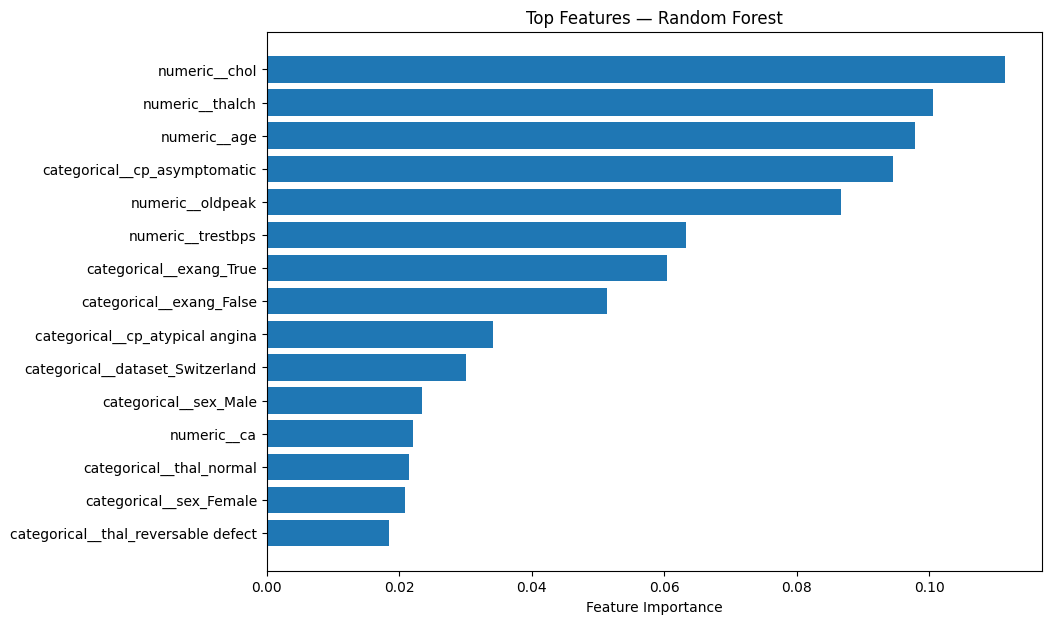

In [51]:
top_features = (
    rf_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top Features — Random Forest"
)

plt.xlabel(
    "Feature Importance"
)

plt.show()

In [52]:
lr_model = (
    logistic_pipeline
    .named_steps["model"]
)

lr_feature_names = (
    logistic_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

lr_coefficients = pd.DataFrame({
    "Feature": lr_feature_names,
    "Coefficient": lr_model.coef_[0]
})

lr_coefficients[
    "Absolute Importance"
] = (
    lr_coefficients["Coefficient"]
    .abs()
)

lr_coefficients = (
    lr_coefficients
    .sort_values(
        "Absolute Importance",
        ascending=False
    )
)

lr_coefficients.head(15)

,Feature,Coefficient,Absolute Importance
10,categorical__dataset_Switzerland,2.081859,2.081859
8,categorical__dataset_Cleveland,-1.249779,1.249779
12,categorical__cp_asymptomatic,0.971183,0.971183
13,categorical__cp_atypical angina,-0.793856,0.793856
9,categorical__dataset_Hungary,-0.734487,0.734487
5,numeric__ca,0.694073,0.694073
4,numeric__oldpeak,0.608704,0.608704
24,categorical__slope_flat,0.605364,0.605364
7,categorical__sex_Male,0.585601,0.585601
22,categorical__exang_True,0.560091,0.560091


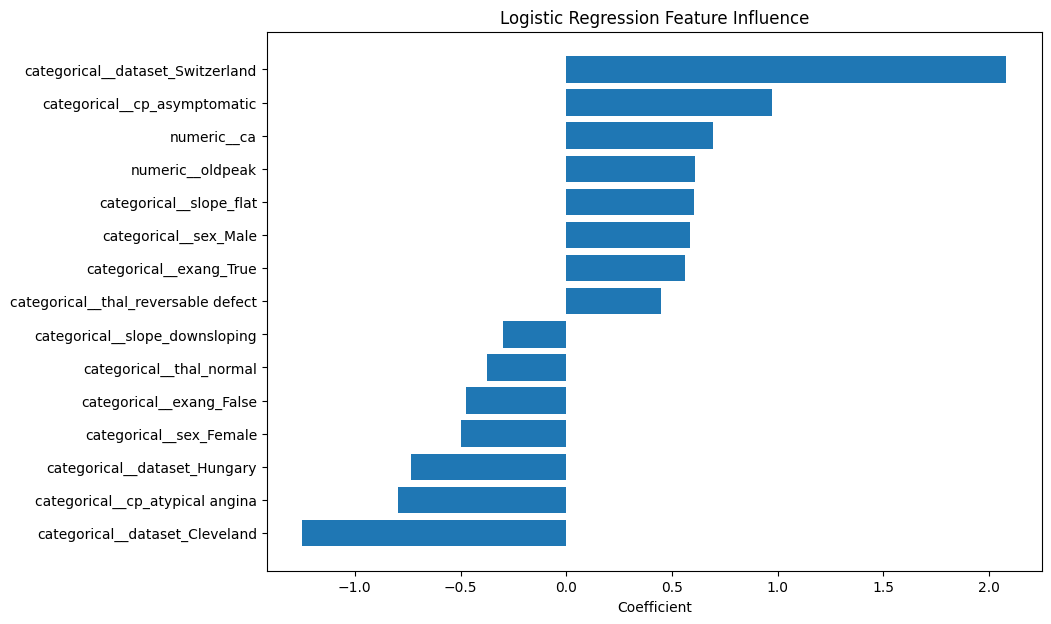

In [53]:
top_lr = (
    lr_coefficients
    .head(15)
    .sort_values(
        "Coefficient"
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_lr["Feature"],
    top_lr["Coefficient"]
)

plt.title(
    "Logistic Regression Feature Influence"
)

plt.xlabel(
    "Coefficient"
)

plt.show()

In [54]:
param_grid = {
    "model__n_estimators": [
        100,
        200,
        300
    ],

    "model__max_depth": [
        None,
        5,
        10,
        15
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ]
}

In [55]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("StratifiedKFold created successfully.")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

StratifiedKFold created successfully.


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['age',
                                                                          'trestbps',
                                                                          'chol',
                                                                          'thalch',
                                                                          'oldpeak',
                                                                          'ca']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequen...
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'dataset',
                                                                          'cp',
                                                                          'fbs',
                                                                          'restecg',
                                                                          'exang',
                                                                          'slope',
                                                                          'thal'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_estimators=300,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10, 15],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200, 300]},
             scoring='roc_auc')

In [56]:
print("Best parameters:")

print(
    grid_search.best_params_
)

print(
    "\nBest cross-validation ROC-AUC:"
)

print(
    grid_search.best_score_
)

Best parameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best cross-validation ROC-AUC:
0.8907165463263024


In [57]:
tuned_rf = (
    grid_search.best_estimator_
)

tuned_rf_predictions = (
    tuned_rf.predict(X_test)
)

tuned_rf_probabilities = (
    tuned_rf.predict_proba(X_test)[:, 1]
)

In [58]:
tuned_results = evaluate_model(
    "Tuned Random Forest",
    y_test,
    tuned_rf_predictions,
    tuned_rf_probabilities
)

pd.DataFrame([
    tuned_results
])

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Random Forest,0.858696,0.851852,0.901961,0.87619,0.934003


In [59]:
final_results = pd.DataFrame([
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_predictions,
        lr_probabilities
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions,
        rf_probabilities
    ),

    evaluate_model(
        "Tuned Random Forest",
        y_test,
        tuned_rf_predictions,
        tuned_rf_probabilities
    )
])

final_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.836957,0.827273,0.892157,0.858491,0.920373
1,Random Forest,0.853261,0.857143,0.882353,0.869565,0.928563
2,Tuned Random Forest,0.858696,0.851852,0.901961,0.876190,0.934003


In [60]:
best_model = final_results.loc[
    final_results["ROC-AUC"].idxmax()
]

print(
    "Best model based on ROC-AUC:"
)

print(
    best_model["Model"]
)

Best model based on ROC-AUC:
Tuned Random Forest


In [61]:
error_analysis = X_test.copy()

error_analysis["Actual"] = (
    y_test.values
)

error_analysis["Predicted"] = (
    tuned_rf_predictions
)

error_analysis["Probability"] = (
    tuned_rf_probabilities
)

error_analysis["Correct"] = (
    error_analysis["Actual"]
    ==
    error_analysis["Predicted"]
)

error_analysis.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,Actual,Predicted,Probability,Correct
514,49,Male,Hungary,asymptomatic,130.0,206.0,False,normal,170.0,False,0.0,NaN,NaN,NaN,1,0,0.342618,False
825,61,Male,VA Long Beach,asymptomatic,120.0,282.0,False,st-t abnormality,135.0,True,4.0,downsloping,NaN,fixed defect,1,1,0.927140,True
854,55,Male,VA Long Beach,asymptomatic,172.0,260.0,False,normal,73.0,False,2.0,NaN,NaN,NaN,1,1,0.676892,True
804,65,Male,VA Long Beach,asymptomatic,136.0,248.0,False,normal,140.0,True,4.0,downsloping,NaN,NaN,1,1,0.970447,True
887,69,Male,VA Long Beach,non-anginal,NaN,271.0,False,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0.617780,False


In [62]:
incorrect_predictions = (
    error_analysis[
        ~error_analysis["Correct"]
    ]
)

print(
    "Incorrect predictions:",
    len(incorrect_predictions)
)

incorrect_predictions

Incorrect predictions: 26


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,Actual,Predicted,Probability,Correct
514,49,Male,Hungary,asymptomatic,130.0,206.0,False,normal,170.0,False,0.0,NaN,NaN,NaN,1,0,0.342618,False
887,69,Male,VA Long Beach,non-anginal,NaN,271.0,False,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0.617780,False
483,59,Male,Hungary,non-anginal,130.0,318.0,False,normal,120.0,True,1.0,flat,NaN,normal,0,1,0.732424,False
278,57,Male,Cleveland,atypical angina,154.0,232.0,False,lv hypertrophy,164.0,False,0.0,upsloping,1.0,normal,1,0,0.369716,False
717,72,Male,Switzerland,non-anginal,160.0,0.0,NaN,lv hypertrophy,114.0,False,1.6,flat,2.0,NaN,0,1,0.847366,False
727,60,Male,VA Long Beach,non-anginal,180.0,0.0,False,st-t abnormality,140.0,True,1.5,flat,NaN,NaN,0,1,0.807448,False
571,55,Male,Hungary,typical angina,140.0,295.0,False,NaN,136.0,False,0.0,NaN,NaN,NaN,1,0,0.335696,False
268,40,Male,Cleveland,asymptomatic,152.0,223.0,False,normal,181.0,False,0.0,upsloping,0.0,reversable defect,1,0,0.280528,False
574,56,Female,Hungary,atypical angina,120.0,279.0,False,normal,150.0,False,1.0,flat,NaN,NaN,1,0,0.053519,False
767,51,Male,VA Long Beach,asymptomatic,128.0,0.0,False,normal,107.0,False,0.0,NaN,NaN,NaN,0,1,0.791304,False


In [63]:
incorrect_predictions.describe(
    include="all"
)

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,Actual,Predicted,Probability,Correct
count,26.000000,26,26,26,24.000000,26.000000,25,25,24.000000,24,24.000000,18,11.000000,12,26.000000,26.000000,26.000000,26
unique,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,2,NaN,2,NaN,NaN,NaN,1
top,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN,NaN,NaN,False
freq,NaN,23,10,10,NaN,NaN,20,14,NaN,17,NaN,14,NaN,6,NaN,NaN,NaN,26
mean,55.769231,NaN,NaN,NaN,133.583333,212.961538,NaN,NaN,142.750000,NaN,1.058333,NaN,1.000000,NaN,0.384615,0.615385,0.556755,NaN
std,9.762408,NaN,NaN,NaN,16.620879,102.040573,NaN,NaN,25.936796,NaN,1.135941,NaN,1.183216,NaN,0.496139,0.496139,0.201231,NaN
min,36.000000,NaN,NaN,NaN,110.000000,0.000000,NaN,NaN,86.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,0.000000,0.053519,NaN
25%,51.000000,NaN,NaN,NaN,120.000000,208.000000,NaN,NaN,123.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,0.000000,0.402819,NaN
50%,57.500000,NaN,NaN,NaN,130.000000,231.000000,NaN,NaN,145.000000,NaN,1.000000,NaN,1.000000,NaN,0.000000,1.000000,0.619348,NaN
75%,62.000000,NaN,NaN,NaN,138.500000,277.000000,NaN,NaN,161.750000,NaN,1.800000,NaN,1.500000,NaN,1.000000,1.000000,0.722048,NaN


In [64]:
def predict_patient(patient_data):

    patient_df = pd.DataFrame(
        [patient_data]
    )

    probability = (
        tuned_rf
        .predict_proba(
            patient_df
        )[0][1]
    )

    prediction = (
        probability >= 0.50
    )

    return {
        "Prediction": (
            "Heart Disease"
            if prediction
            else "No Heart Disease"
        ),

        "Probability": round(
            probability,
            3
        ),

        "Risk Category": risk_category(
            probability
        )
    }

In [65]:
sample_patient = (
    X_test.iloc[0].to_dict()
)

sample_patient

{'age': 49,
 'sex': 'Male',
 'dataset': 'Hungary',
 'cp': 'asymptomatic',
 'trestbps': 130.0,
 'chol': 206.0,
 'fbs': False,
 'restecg': 'normal',
 'thalch': 170.0,
 'exang': False,
 'oldpeak': 0.0,
 'slope': nan,
 'ca': nan,
 'thal': nan}

In [66]:
predict_patient(
    sample_patient
)

{'Prediction': 'No Heart Disease',
 'Probability': np.float64(0.343),
 'Risk Category': 'Moderate'}

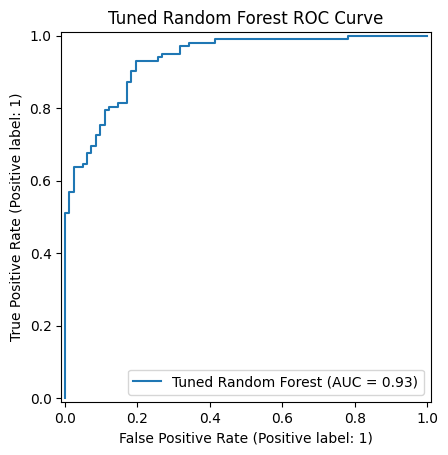

In [67]:
RocCurveDisplay.from_predictions(
    y_test,
    tuned_rf_probabilities,
    name="Tuned Random Forest"
)

plt.title(
    "Tuned Random Forest ROC Curve"
)

plt.show()

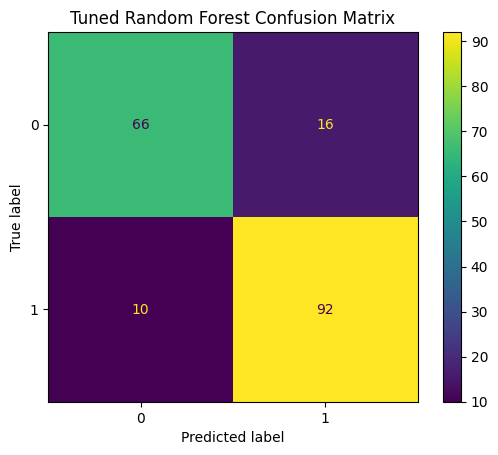

In [68]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_rf_predictions
)

plt.title(
    "Tuned Random Forest Confusion Matrix"
)

plt.show()